In [140]:
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [112]:
def load_all_data_from_json(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

In [113]:
def load_values_from_json(file_path):
    with open(file_path, "r") as file:
        data_org = json.load(file)
    return list(data_org.values())

In [114]:
def get_files_with_cd(file_path, data_values, th):
    all_data = load_all_data_from_json(file_path)
    threshold = th
    keys_above_threshold = [key for key, value in all_data.items() if value > threshold]
    
    print(f"\nObjects whith Chamfer > {threshold}:")
    for key in keys_above_threshold:
        print(key)

    # Total number of files
    print(f"\nNumber of objects with Chamfer > {threshold}: {len(keys_above_threshold)} of {len(data_values)}")

In [115]:
def generate_histogram(data, bins, alpha, title, class_labels, means, colors):
    bins = 50
    plt.figure(figsize=(8, 4))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(means[i], color=colors[i], linestyle='--', linewidth=1.5, label=f"{class_labels[i]} Mean: {round(means[i], 3)}")

    # Add legend and labels
    plt.legend()
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

In [171]:
mpl.rcParams.update({
    'svg.fonttype': 'none',        # texto editable en SVG
    'pdf.fonttype': 42,            # texto como texto, no curvas
    'font.family': 'STIXGeneral',  # "Times-like" portátil
    'mathtext.fontset': 'stix'
})

In [172]:
def generate_histogram_and_save(data, bins, alpha, title, class_labels, means, colors, output_path):
    
    bins = 50
    plt.figure(figsize=(6, 4))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(means[i], color=colors[i], linestyle='--', linewidth=1.5, label=f"{class_labels[i]} Mean: {round(means[i], 3)}")

    # Add legend and labels
    plt.legend()
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.tight_layout()

    pdf_path = output_path.replace('.svg', '.pdf')
    plt.savefig(pdf_path, format='pdf', transparent=False)
    plt.show()
    plt.close()
    print(f"✅ Histograma guardado en: {output_path}")

# ShapeNet 1000 Objects

## Centroid x = 0

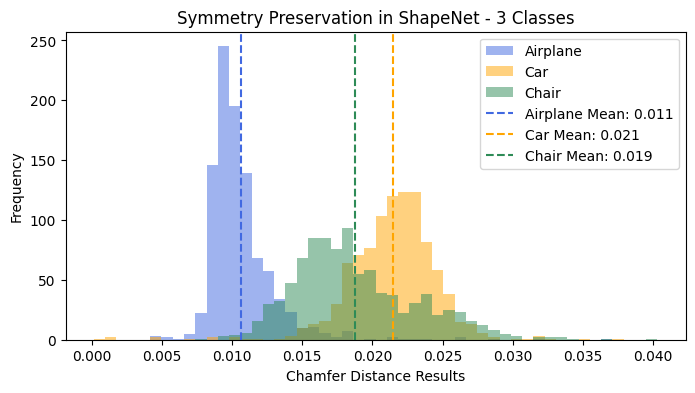

In [116]:
file_path_airplane = "Symmetry_Computation/Results_CD/centered_shapenet1000_cd_results_airplane.json"
shapenet1000_airplane_data = load_values_from_json(file_path_airplane)  # Limiting to 405 samples
airplane_mean = np.mean(shapenet1000_airplane_data)

file_path_car = "Symmetry_Computation/Results_CD/centered_shapenet1000_cd_results_car.json"
shapenet1000_car_data = load_values_from_json(file_path_car)  # Limiting to 405 samples
car_mean = np.mean(shapenet1000_car_data)

file_path_chair = "Symmetry_Computation/Results_CD/centered_shapenet1000_cd_results_chair.json"
shapenet1000_chair_data = load_values_from_json(file_path_chair)  # Limiting to 405 samples
chair_mean = np.mean(shapenet1000_chair_data)

data = [shapenet1000_airplane_data, shapenet1000_car_data, shapenet1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [airplane_mean, car_mean, chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Preservation in ShapeNet - 3 Classes", class_labels=class_labels, means=means, colors=colors)

# Objects with CD greater than 0.03
#get_files_with_cd(file_path, data, 0.03)

## Original Objects

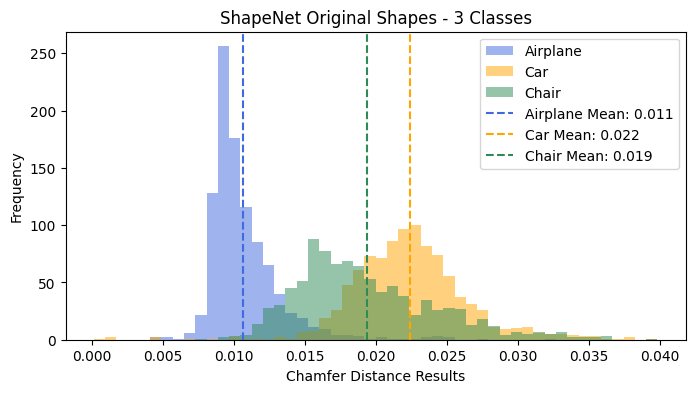

In [117]:
file_path_airplane = "Symmetry_Computation/Results_CD/shapenet1000_cd_results_airplane.json"
shapenet1000_airplane_data = load_values_from_json(file_path_airplane)
airplane_mean = np.mean(shapenet1000_airplane_data)

file_path_car = "Symmetry_Computation/Results_CD/shapenet1000_cd_results_car.json"
shapenet1000_car_data = load_values_from_json(file_path_car)
car_mean = np.mean(shapenet1000_car_data)

file_path_chair = "Symmetry_Computation/Results_CD/shapenet1000_cd_results_chair.json"
shapenet1000_chair_data = load_values_from_json(file_path_chair)
chair_mean = np.mean(shapenet1000_chair_data)

data = [shapenet1000_airplane_data, shapenet1000_car_data, shapenet1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [airplane_mean, car_mean, chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="ShapeNet Original Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

# Objects with CD greater than 0.03
#get_files_with_cd(file_path, data, 0.03)

# PVD

## Original CKPT

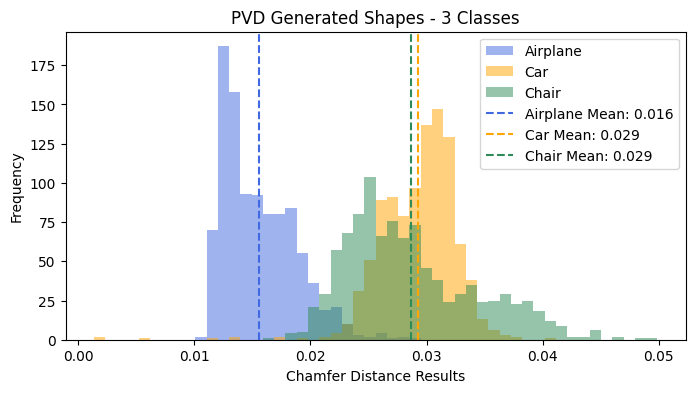

In [118]:
file_path = "Symmetry_Computation/Results_CD/centered_pvd1000_cd_results_airplane.json"
pvd1000_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
pvd_original_airplane_mean = np.mean(pvd1000_airplane_data)

file_path = "Symmetry_Computation/Results_CD/centered_pvd1000_cd_results_car.json"
pvd1000_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
pvd_original_car_mean = np.mean(pvd1000_car_data)

file_path = "Symmetry_Computation/Results_CD/centered_pvd1000_cd_results_chair.json"
pvd1000_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
pvd_original_chair_mean = np.mean(pvd1000_chair_data)

data = [pvd1000_airplane_data, pvd1000_car_data, pvd1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [pvd_original_airplane_mean, pvd_original_car_mean, pvd_original_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

## Over Half Objects

### Airplane

In [119]:
file_path = "Symmetry_Computation/Results_CD_Over_Half/cd_res_PVD_airplane.json"
s_pvd_airplane_data = load_values_from_json(file_path)
s_pvd_airplane_mean = np.mean(s_pvd_airplane_data)

data = [s_pvd_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_pvd_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

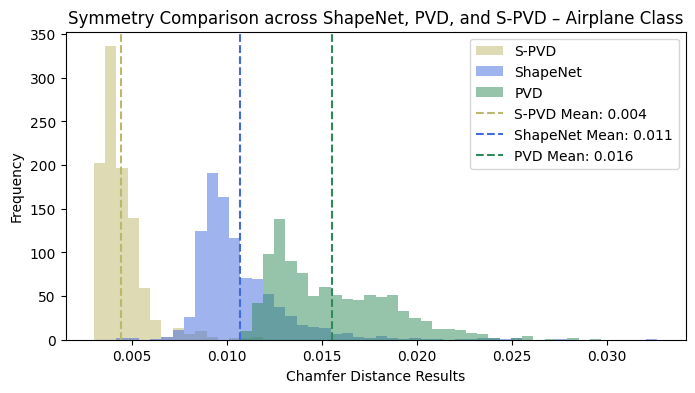

In [120]:
data = [s_pvd_airplane_data, shapenet1000_airplane_data, pvd1000_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-PVD", "ShapeNet", "PVD"] # , "Car", "Chair"
means = [s_pvd_airplane_mean, airplane_mean, pvd_original_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, and S-PVD – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [121]:
file_path = "Symmetry_Computation/Results_CD_Over_Half/cd_res_PVD_car.json"
s_pvd_car_data = load_values_from_json(file_path)
s_pvd_car_mean = np.mean(s_pvd_car_data)

data = [s_pvd_airplane_data]
class_labels = ["Car"]
means = [s_pvd_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

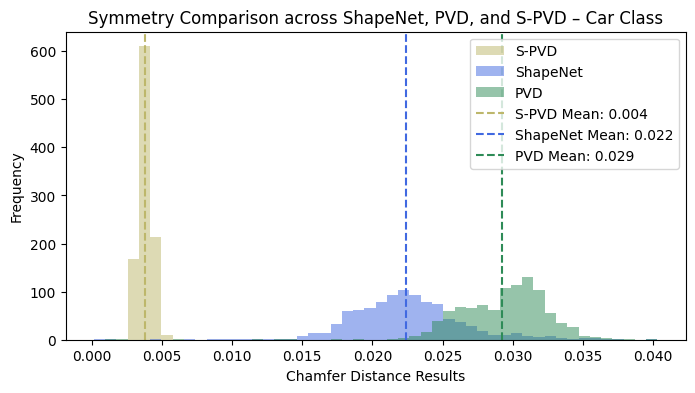

In [122]:
data = [s_pvd_car_data, shapenet1000_car_data, pvd1000_car_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-PVD", "ShapeNet", "PVD"] # , "Car", "Chair"
means = [s_pvd_car_mean, car_mean, pvd_original_car_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, and S-PVD – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [123]:
file_path = "Symmetry_Computation/Results_CD_Over_Half/cd_res_PVD_chair.json"
s_pvd_chair_data = load_values_from_json(file_path)
s_pvd_chair_mean = np.mean(s_pvd_chair_data)

data = [s_pvd_chair_data]
class_labels = ["Chair"]
means = [s_pvd_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

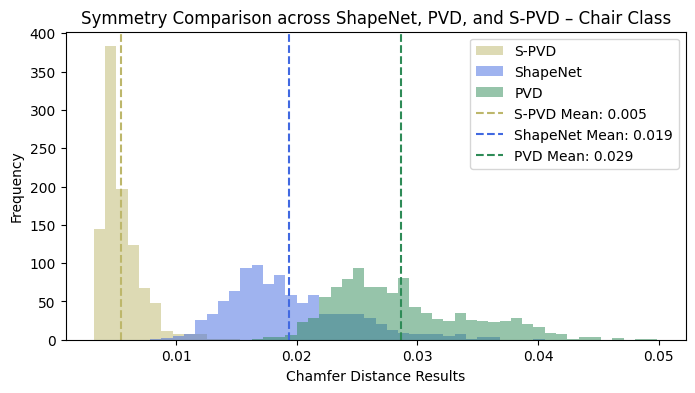

In [124]:
data = [s_pvd_chair_data, shapenet1000_chair_data, pvd1000_chair_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-PVD", "ShapeNet", "PVD"] # , "Chair", "Chair"
means = [s_pvd_chair_mean, chair_mean, pvd_original_chair_mean] # , pvd_Chair_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, and S-PVD – Chair Class", class_labels=class_labels, means=means, colors=colors)

# LION

## Original CKPT

1000
1000
1000


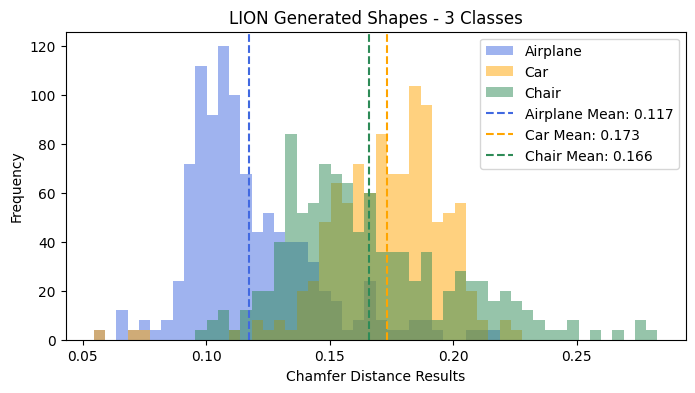

In [125]:
file_path = "Symmetry_Computation/Results_CD/centered_lion250_cd_results_airplane.json"
lion250_airplane_data = load_values_from_json(file_path)
lion_airplane_mean = np.mean(lion250_airplane_data)

file_path = "Symmetry_Computation/Results_CD/centered_lion250_cd_results_car.json"
lion250_car_data = load_values_from_json(file_path)
lion_car_mean = np.mean(lion250_car_data)

file_path = "Symmetry_Computation/Results_CD/centered_lion250_cd_results_chair.json"
lion250_chair_data = load_values_from_json(file_path)
lion_chair_mean = np.mean(lion250_chair_data)

print(len(lion250_airplane_data))
print(len(lion250_car_data))
print(len(lion250_chair_data))

data = [lion250_airplane_data, lion250_car_data, lion250_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [lion_airplane_mean, lion_car_mean, lion_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="LION Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

## Over Half Objects

### Airplane

In [126]:
file_path = "Symmetry_Computation/Results_CD_Over_Half/cd_res_LION_airplane.json"
s_lion_airplane_data = load_values_from_json(file_path)
s_lion_airplane_mean = np.mean(s_lion_airplane_data)

data = [s_lion_airplane_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_lion_airplane_mean] # , lion_car_mean, lion_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="lion Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

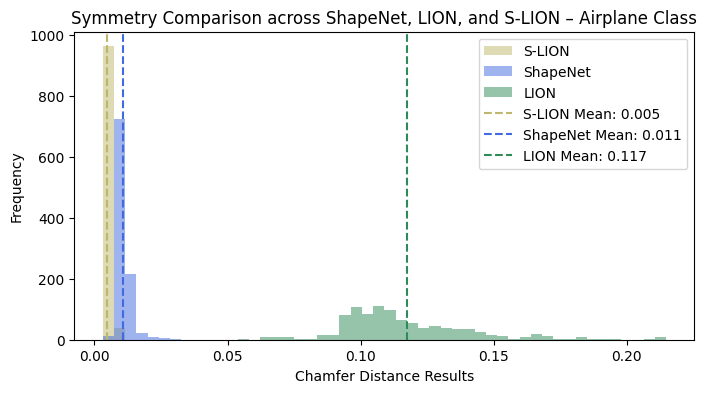

In [127]:
data = [s_lion_airplane_data, shapenet1000_airplane_data, lion250_airplane_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["S-LION", "ShapeNet", "LION"] # , "Car", "Chair"
means = [s_lion_airplane_mean, airplane_mean, lion_airplane_mean] # , lion_car_mean, lion_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, LION, and S-LION – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [128]:
file_path = "Symmetry_Computation/Results_CD_Over_Half/cd_res_LION_car.json"
s_lion_car_data = load_values_from_json(file_path)
s_lion_car_mean = np.mean(s_lion_car_data)

data = [s_lion_airplane_data]
class_labels = ["Car"]
means = [s_lion_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="LION Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

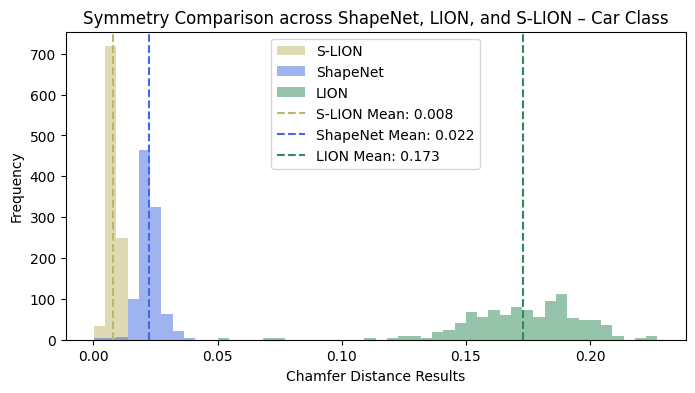

In [129]:
data = [s_lion_car_data, shapenet1000_car_data, lion250_car_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["S-LION", "ShapeNet", "LION"] # , "Car", "Chair"
means = [s_lion_car_mean, car_mean, lion_car_mean] # , lion_car_mean, lion_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, LION, and S-LION – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [130]:
file_path = "Symmetry_Computation/Results_CD_Over_Half/cd_res_LION_chair.json"
s_lion_chair_data = load_values_from_json(file_path)
s_lion_chair_mean = np.mean(s_lion_chair_data)

data = [s_lion_chair_data]
class_labels = ["Chair"]
means = [s_lion_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="LION Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

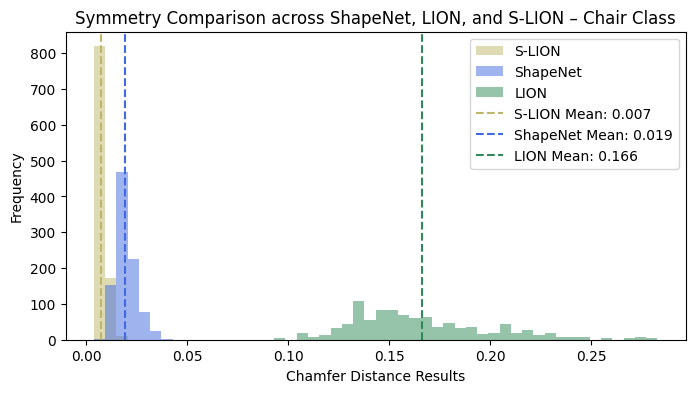

In [131]:
data = [s_lion_chair_data, shapenet1000_chair_data, lion250_chair_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["S-LION", "ShapeNet", "LION"] # , "Chair", "Chair"
means = [s_lion_chair_mean, chair_mean, lion_chair_mean] # , lion_Chair_mean, lion_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, LION, and S-LION – Chair Class", class_labels=class_labels, means=means, colors=colors)

# Joint histograms

## Airplane

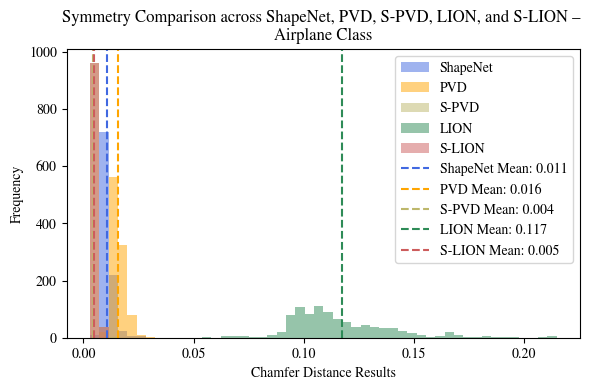

✅ Histograma guardado en: s-airplane.pdf


In [173]:
data = [shapenet1000_airplane_data, pvd1000_airplane_data, s_pvd_airplane_data, lion250_airplane_data, s_lion_airplane_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["ShapeNet", "PVD", "S-PVD", "LION", "S-LION"] # , "Car", "Chair"
means = [airplane_mean, pvd_original_airplane_mean, s_pvd_airplane_mean, lion_airplane_mean, s_lion_airplane_mean] # , lion_car_mean, lion_chair_mean
colors = ["royalblue", "orange", "darkkhaki", "seagreen", "indianred"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram_and_save(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, S-PVD, LION, and S-LION – \nAirplane Class", class_labels=class_labels, means=means, colors=colors, output_path="s-airplane.pdf")

## Car

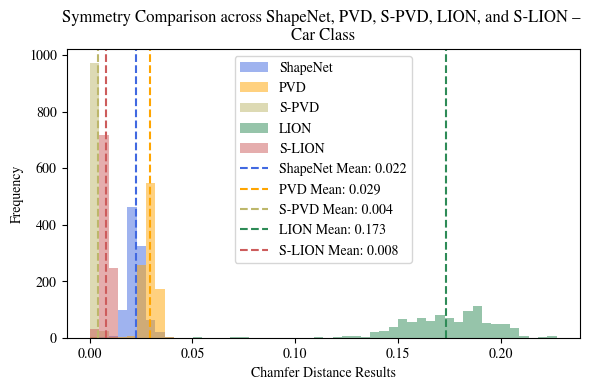

✅ Histograma guardado en: s-car.pdf


In [174]:
data = [shapenet1000_car_data, pvd1000_car_data, s_pvd_car_data, lion250_car_data, s_lion_car_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["ShapeNet", "PVD", "S-PVD", "LION", "S-LION"] # , "Car", "Chair"
means = [car_mean, pvd_original_car_mean, s_pvd_car_mean, lion_car_mean, s_lion_car_mean] # , lion_car_mean, lion_chair_mean
colors = ["royalblue", "orange", "darkkhaki", "seagreen", "indianred"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram_and_save(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, S-PVD, LION, and S-LION – \nCar Class", class_labels=class_labels, means=means, colors=colors, output_path="s-car.pdf")

## Chair

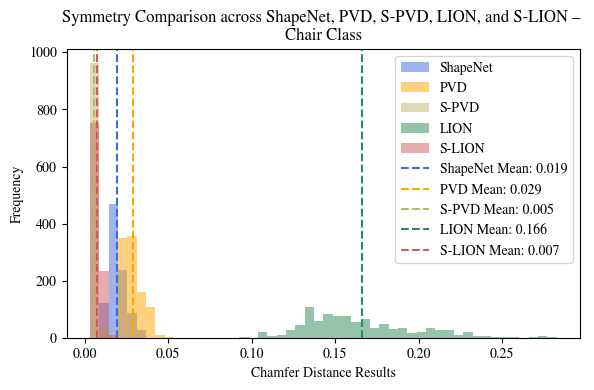

✅ Histograma guardado en: s-chair.pdf


In [175]:
data = [shapenet1000_chair_data, pvd1000_chair_data, s_pvd_chair_data, lion250_chair_data, s_lion_chair_data] # , lion1000_chair_data, lion1000_chair_data
class_labels = ["ShapeNet", "PVD", "S-PVD", "LION", "S-LION"] # , "chair", "Chair"
means = [chair_mean, pvd_original_chair_mean, s_pvd_chair_mean, lion_chair_mean, s_lion_chair_mean] # , lion_chair_mean, lion_chair_mean
colors = ["royalblue", "orange", "darkkhaki", "seagreen", "indianred"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram_and_save(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, S-PVD, LION, and S-LION – \nChair Class", class_labels=class_labels, means=means, colors=colors, output_path="s-chair.pdf")